# Exercises XP: Introduction to LLMs


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
LLMs are models pretrained on a large amount of text data capable to understand and generate natural language


### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [ ]:
%pip install --quiet transformers matplotlib --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 36.7 MB/s eta 0:00:00


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = "gpt2"  # choose a causal LM checkpoint, e.g., 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)  # load AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)      # load AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


TODO: Describe the tokenization process in your own words before coding.


Original Text: LLMs are models pretrained on a large amount of text data capable to understand and generate natural language
Tokens: ['LL', 'Ms', 'Ġare', 'Ġmodels', 'Ġpret', 'rained', 'Ġon', 'Ġa', 'Ġlarge', 'Ġamount', 'Ġof', 'Ġtext', 'Ġdata', 'Ġcapable', 'Ġto', 'Ġunderstand', 'Ġand', 'Ġgenerate', 'Ġnatural', 'Ġlanguage']
Token IDs: [3069, 10128, 389, 4981, 2181, 13363, 319, 257, 1588, 2033, 286, 2420, 1366, 6007, 284, 1833, 290, 7716, 3288, 3303]


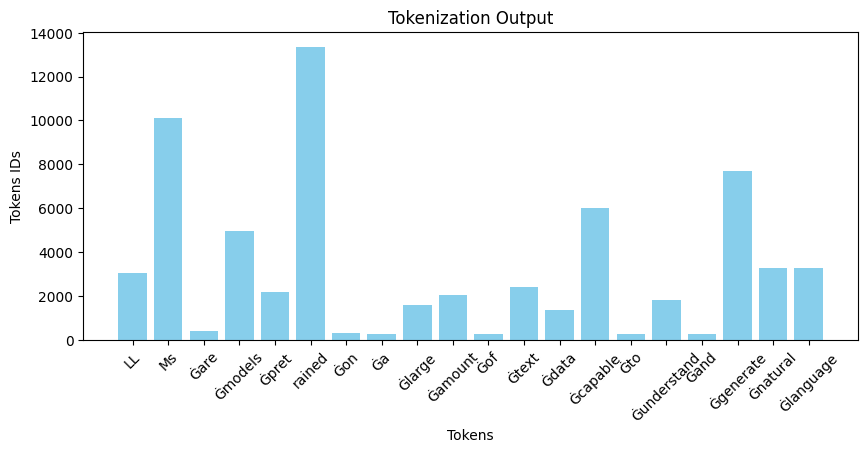

In [ ]:
text = "LLMs are models pretrained on a large amount of text data capable to understand and generate natural language"  # TODO: provide a sentence of your choice
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)         # tokenize the input
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # convert to ids

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = "Tokens"  # label for the x-axis (e.g., "Tokens")
y_label = "Tokens IDs"  # label for the y-axis (e.g., "Token IDs")
title = "Tokenization Output"    # chart title

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()


## 🌟 Exercise 3 · Token IDs and special prefixes


In [ ]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# TODO: print the token along with its numeric id
raise NotImplementedError("Iterate over `tokens` and `token_ids`, printing each mapping.")


NotImplementedError: Iterate over `tokens` and `token_ids`, printing each mapping.

TODO: In plain language, explain what the `Ġ` prefix indicates in GPT-style vocabularies.



In GPT-style tokenization, the Ġ prefix indicates that a token begins with a preceding space.
Spaces are represanted with Ġ in GPT-2.

## 🌟 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [ ]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text =  "Answer the following question factually: What is the language of Morocco?"  # write a brand-new prompt
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,  # adjust if you want longer/shorter outputs
    "temperature": 0.95,    # tune sampling temperature
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)  # call the generator
output_text = output_ids[0]["generated_text"]     # extract the text string

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")


Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Input: Answer the following question factually: What is the language of Morocco?
Generated Output: Answer the following question factually: What is the language of Morocco? A. The language of Morocco is Arabic. B. The language of Morocco is Morocco. C. The language of Morocco is English. D. The language of Morocco is French. E. The language of Morocco is Arabic. F. The language of Morocco is English.


Question: If Morocco


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?

after updating each knobs continuously, I think that that the temperature change the style most


Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)